# **Assignment 2 - Soen 471**

In [63]:
import warnings
import logging

# Suppress DeprecationWarnings coming from the jupyter_client library and others
warnings.filterwarnings('ignore')


### Imports

In [33]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from sklearn.model_selection import train_test_split
from mlxtend.preprocessing import TransactionEncoder
from sklearn.metrics.pairwise import cosine_similarity
from mlxtend.frequent_patterns import apriori, association_rules

## 1. Data PreProcessing

### 1.1 Loading and cleaning data

In [34]:
# Load data
user_data = pd.read_csv('ecommerce_user_data.csv')
product_data = pd.read_csv('product_details.csv')

print(user_data.head())
print(product_data.head())

  UserID ProductID  Rating   Timestamp  Category
0   U000     P0009       5  2024-09-08     Books
1   U000     P0020       1  2024-09-02      Home
2   U000     P0012       4  2024-10-18     Books
3   U000     P0013       1  2024-09-18  Clothing
4   U000     P0070       4  2024-09-16      Toys
  ProductID      ProductName     Category
0     P0000      Toys Item 0     Clothing
1     P0001  Clothing Item 1  Electronics
2     P0002     Books Item 2  Electronics
3     P0003  Clothing Item 3  Electronics
4     P0004  Clothing Item 4  Electronics


In [35]:
print("\nUser Data Info:")
print(user_data.info())

print("\nProduct Data Info:")
print(product_data.info())

print("\nMissing Values in User Data:")
print(user_data.isnull().sum())

print("\nMissing Values in Product Data:")
print(product_data.isnull().sum())


User Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 724 entries, 0 to 723
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   UserID     724 non-null    object
 1   ProductID  724 non-null    object
 2   Rating     724 non-null    int64 
 3   Timestamp  724 non-null    object
 4   Category   724 non-null    object
dtypes: int64(1), object(4)
memory usage: 28.4+ KB
None

Product Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ProductID    100 non-null    object
 1   ProductName  100 non-null    object
 2   Category     100 non-null    object
dtypes: object(3)
memory usage: 2.5+ KB
None

Missing Values in User Data:
UserID       0
ProductID    0
Rating       0
Timestamp    0
Category     0
dtype: int64

Missing Values in Product Data:
ProductID      0
ProductNa

There is no null data that we need to remove, however we will still drop duplicates for a cleaner dataset.

In [36]:
user_data = user_data.drop_duplicates()
product_data = product_data.drop_duplicates()

print(user_data.head())
print(product_data.head())

  UserID ProductID  Rating   Timestamp  Category
0   U000     P0009       5  2024-09-08     Books
1   U000     P0020       1  2024-09-02      Home
2   U000     P0012       4  2024-10-18     Books
3   U000     P0013       1  2024-09-18  Clothing
4   U000     P0070       4  2024-09-16      Toys
  ProductID      ProductName     Category
0     P0000      Toys Item 0     Clothing
1     P0001  Clothing Item 1  Electronics
2     P0002     Books Item 2  Electronics
3     P0003  Clothing Item 3  Electronics
4     P0004  Clothing Item 4  Electronics


### 1.2 Merging data

In [37]:
#Data will be merged based on the ProductID, this will make data agregation simpler.
merged_data = pd.merge(user_data, product_data, on='ProductID', how='left')
print("\nMerged Data Preview:")
print(merged_data.head())


Merged Data Preview:
  UserID ProductID  Rating   Timestamp Category_x       ProductName Category_y
0   U000     P0009       5  2024-09-08      Books   Clothing Item 9      Books
1   U000     P0020       1  2024-09-02       Home  Clothing Item 20       Home
2   U000     P0012       4  2024-10-18      Books    Beauty Item 12      Books
3   U000     P0013       1  2024-09-18   Clothing  Clothing Item 13   Clothing
4   U000     P0070       4  2024-09-16       Toys    Beauty Item 70       Toys


In [38]:
#This created 2 columns for CategoricalAccessor, we will need to check if columns are identical if that is the case we can merge them together
(merged_data['Category_x'] == merged_data['Category_y']).all()

merged_data = merged_data.drop(columns=['Category_x'])
merged_data = merged_data.rename(columns={'Category_y': 'Category'})

print(merged_data.head())

  UserID ProductID  Rating   Timestamp       ProductName  Category
0   U000     P0009       5  2024-09-08   Clothing Item 9     Books
1   U000     P0020       1  2024-09-02  Clothing Item 20      Home
2   U000     P0012       4  2024-10-18    Beauty Item 12     Books
3   U000     P0013       1  2024-09-18  Clothing Item 13  Clothing
4   U000     P0070       4  2024-09-16    Beauty Item 70      Toys


 ### 1.3 Converting ratings into a user-item Matrix

In [39]:
user_item_matrix = merged_data.pivot_table(index='UserID', columns='ProductID', values='Rating')
user_item_matrix_filled = user_item_matrix.fillna(0)

# Compute user similarity using cosine similarity

user_similarity = cosine_similarity(user_item_matrix_filled)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix_filled.index,
    columns=user_item_matrix_filled.index
)

user_similarity_df.head()

UserID,U000,U001,U002,U003,U004,U005,U006,U007,U008,U009,...,U040,U041,U042,U043,U044,U045,U046,U047,U048,U049
UserID,,,,,,,,,,,,,,,,,,,,,
U000,1.000000,0.063071,0.195522,0.023466,0.065412,0.161251,0.160096,0.092083,0.238263,0.274844,...,0.241693,0.129483,0.156790,0.132200,0.161478,0.100346,0.126917,0.150727,0.000000,0.104294
U001,0.063071,1.000000,0.190861,0.000000,0.111332,0.009540,0.000000,0.172286,0.167460,0.017593,...,0.121540,0.024075,0.097953,0.007821,0.000000,0.000000,0.193670,0.247805,0.000000,0.000000
U002,0.195522,0.190861,1.000000,0.065094,0.111662,0.050830,0.027756,0.055877,0.000000,0.181229,...,0.144756,0.000000,0.217465,0.000000,0.055992,0.034794,0.194243,0.110030,0.177165,0.000000
U003,0.023466,0.000000,0.065094,1.000000,0.035737,0.104116,0.026650,0.000000,0.025384,0.288009,...,0.243836,0.000000,0.000000,0.074688,0.197121,0.000000,0.054396,0.126773,0.374228,0.250000
U004,0.065412,0.111332,0.111662,0.035737,1.000000,0.159064,0.057144,0.026294,0.195942,0.247023,...,0.062741,0.116202,0.078797,0.048044,0.103747,0.133716,0.124969,0.217464,0.255318,0.172729


### 1.4 Aggregate user behavior by category

In [40]:
user_category_agg = merged_data.groupby(['UserID', 'Category']).agg({'Rating': ['count', 'mean']}).reset_index()
user_category_agg.columns = ['UserID', 'Category', 'TotalInteractions', 'AverageRating']
user_category_agg.head()

,UserID,Category,TotalInteractions,AverageRating
0,U000,Books,6,3.666667
1,U000,Clothing,3,1.666667
2,U000,Electronics,3,3.666667
3,U000,Home,2,1.000000
4,U000,Toys,6,3.500000


# Part 2: User-Based Collaborative Filtering (Cosine Similarity)

This section implements a recommender system using user-based collaborative filtering.
We compute similarity between users and recommend products based on similar users' preferences.

## Step 1: Load Dataset
We load the e-commerce user interaction dataset.

In [41]:
df = pd.read_csv('ecommerce_user_data.csv')
df.head()

,UserID,ProductID,Rating,Timestamp,Category
0,U000,P0009,5,2024-09-08,Books
1,U000,P0020,1,2024-09-02,Home
2,U000,P0012,4,2024-10-18,Books
3,U000,P0013,1,2024-09-18,Clothing
4,U000,P0070,4,2024-09-16,Toys


## Step 2: Train-Test Split

We split the data into training and testing sets per user to simulate real-world recommendations.

In [42]:
# Split the data into training and testing sets per user to simulate real-world recommendations
train_list = []
test_list = []

for user in df['UserID'].unique():
    user_data = df[df['UserID'] == user]

    if len(user_data) > 1:
        train, test = train_test_split(user_data, test_size=0.2, random_state=42)
        train_list.append(train)
        test_list.append(test)

train_df = pd.concat(train_list)
test_df = pd.concat(test_list)

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (562, 5)
Test size: (162, 5)


## Step 3: Create User-Item Matrix

Rows represent users, columns represent products, and values represent ratings.

In [43]:
user_item_matrix = train_df.pivot_table(
    index='UserID',
    columns='ProductID',
    values='Rating'
).fillna(0)

user_item_matrix.head()

ProductID,P0000,P0001,P0002,P0003,P0004,P0005,P0006,P0007,P0008,P0009,...,P0090,P0091,P0092,P0093,P0094,P0095,P0096,P0097,P0098,P0099
UserID,,,,,,,,,,,,,,,,,,,,,
U000,0.0,0.0,0.0,0.0,0.0,5.0,0.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
U001,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,5.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0
U002,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
U003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
U004,0.0,3.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,3.0


## Step 4: Compute User Similarity

We calculate cosine similarity between users based on their rating patterns.

In [44]:

user_similarity = cosine_similarity(user_item_matrix)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

user_similarity_df.head()

UserID,U000,U001,U002,U003,U004,U005,U006,U007,U008,U009,...,U040,U041,U042,U043,U044,U045,U046,U047,U048,U049
UserID,,,,,,,,,,,,,,,,,,,,,
U000,1.000000,0.048678,0.206982,0.040489,0.059436,0.181824,0.199212,0.083820,0.073922,0.317270,...,0.150997,0.088901,0.209251,0.015414,0.162437,0.126724,0.100939,0.111694,0.000000,0.000000
U001,0.048678,1.000000,0.206959,0.000000,0.000000,0.000000,0.000000,0.204446,0.144726,0.000000,...,0.052406,0.000000,0.127819,0.000000,0.000000,0.000000,0.256906,0.103374,0.000000,0.000000
U002,0.206982,0.206959,1.000000,0.109545,0.080403,0.055902,0.033686,0.066144,0.000000,0.063324,...,0.148556,0.000000,0.283069,0.000000,0.067612,0.042857,0.257030,0.137361,0.040614,0.000000
U003,0.040489,0.000000,0.109545,1.000000,0.073398,0.000000,0.046127,0.000000,0.042133,0.269763,...,0.084758,0.000000,0.000000,0.000000,0.092582,0.000000,0.000000,0.175549,0.000000,0.259938
U004,0.059436,0.000000,0.080403,0.073398,1.000000,0.213497,0.084639,0.037987,0.208739,0.325285,...,0.037326,0.166195,0.056899,0.031435,0.042471,0.000000,0.121090,0.331326,0.234706,0.085855


## Step 5: Find Similar Users

This function returns top similar users for a given user.

In [45]:
def get_similar_users(user_id, top_n=5):
    # Check if the user_id exists in the similarity DataFrame
    if user_id not in user_similarity_df:
        return pd.Series()

    # Retrieve the similarity scores for the given user and sort them in descending order
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)

    # Remove the user itself from the list of similar users
    similar_users = similar_users.drop(user_id)

    # Return the top_n most similar users
    return similar_users.head(top_n)

get_similar_users('U001')

,U001
UserID,
U017,0.343574
U012,0.289379
U046,0.256906
U024,0.252840
U011,0.252422


## Step 6: Generate Recommendations

We recommend products liked by similar users but not yet rated by the target user.

In [46]:
def recommend_products(user_id, top_n=5):
    # Check if the user exists in the user-item matrix; if not, return an empty series
    if user_id not in user_item_matrix.index:
        return pd.Series()

    # Get the top similar users to the target user
    similar_users = get_similar_users(user_id, top_n=5)

    # Get the items rated by the target user (ratings > 0)
    user_rated = user_item_matrix.loc[user_id]
    user_rated_items = user_rated[user_rated > 0].index

    # Initialize a series to accumulate recommendation scores
    scores = pd.Series(dtype='float64')

    # For each similar user, add their ratings weighted by similarity score
    for sim_user, sim_score in similar_users.items():
        sim_ratings = user_item_matrix.loc[sim_user]
        scores = scores.add(sim_ratings * sim_score, fill_value=0)

    # Remove items already rated by the target user
    scores = scores.drop(user_rated_items, errors='ignore')

    # Return the top_n items with the highest scores
    return scores.sort_values(ascending=False).head(top_n)

recommend_products('U001')

,0
ProductID,
P0062,2.401920
P0015,2.131563
P0018,2.020630
P0064,1.960705
P0008,1.895759


## Step 7: Evaluation Metrics

We evaluate recommendation quality using Precision@K and Recall@K.

In [47]:
def precision_at_k(recommended, relevant, k=5):
    """
    Calculate Precision@K: the fraction of recommended items in the top-k that are relevant.

    Args:
        recommended (list): List of recommended items.
        relevant (list): List of relevant items.
        k (int): Number of top recommendations to consider (default: 5).

    Returns:
        float: Precision@K value.
    """
    recommended_k = recommended[:k]
    relevant_set = set(relevant)

    hits = len([item for item in recommended_k if item in relevant_set])
    return hits / k if k > 0 else 0


def recall_at_k(recommended, relevant, k=5):
    """
    Calculate Recall@K: the fraction of relevant items that are in the top-k recommendations.

    Args:
        recommended (list): List of recommended items.
        relevant (list): List of relevant items.
        k (int): Number of top recommendations to consider (default: 5).

    Returns:
        float: Recall@K value.
    """
    recommended_k = recommended[:k]
    relevant_set = set(relevant)

    hits = len([item for item in recommended_k if item in relevant_set])
    return hits / len(relevant_set) if relevant_set else 0

## Step 8: Evaluate Model Performance

We evaluate the model across all users using test data.

In [48]:
# Initialize lists to store precision and recall values for each user
precisions = []
recalls = []

# Loop through each unique user in the test dataset
for user in test_df['UserID'].unique():
    # Get the list of recommended product IDs for the user (top 5 by default)
    recommended = recommend_products(user).index.tolist()
    # Get the list of relevant product IDs from the test data for the user
    relevant = test_df[test_df['UserID'] == user]['ProductID'].tolist()

    # Only evaluate if there are both recommended and relevant items
    if len(recommended) > 0 and len(relevant) > 0:
        # Calculate and append precision@5 and recall@5 for this user
        precisions.append(precision_at_k(recommended, relevant))
        recalls.append(recall_at_k(recommended, relevant))

# Print the average precision and recall across all users
print("Average Precision@5:", np.mean(precisions))
print("Average Recall@5:", np.mean(recalls))

Average Precision@5: 0.032
Average Recall@5: 0.05


## Step 9: Conclusion

The model shows low precision and recall due to data sparsity and limited overlap between users.

User-based collaborative filtering depends heavily on shared user preferences, which are weak in this dataset.

Future improvements may include:
- Increasing neighborhood size
- Normalizing ratings
- Using model-based approaches

# Part 3: Association Rule Mining (Apriori)

In this section we will:


1.   Build transactions based on user-product purchases.
2.   Implemente Apriori algorithm to find frequent itemsets.
3.  Generate association rules and evaluate them based on support, confidence and lift.
4.  And finally, we will visualize frequent itemsets with barchats and netowrk diagrams.


### (3.1) Load Data

In [49]:
ecommerce_user_data = pd.read_csv('ecommerce_user_data.csv')
product_details = pd.read_csv('product_details.csv')

print(ecommerce_user_data.shape, product_details.shape)
ecommerce_user_data.head()

(724, 5) (100, 3)


,UserID,ProductID,Rating,Timestamp,Category
0,U000,P0009,5,2024-09-08,Books
1,U000,P0020,1,2024-09-02,Home
2,U000,P0012,4,2024-10-18,Books
3,U000,P0013,1,2024-09-18,Clothing
4,U000,P0070,4,2024-09-16,Toys


### (3.2) Data Exploration

In [50]:
print("Unique users:", ecommerce_user_data['UserID'].nunique())
print("Unique products:", ecommerce_user_data['ProductID'].nunique())
print("Transactions (rows):", len(ecommerce_user_data))

print("\nMissing values in ecommerce_user_data:")
print(ecommerce_user_data.isnull().sum())

Unique users: 50
Unique products: 100
Transactions (rows): 724

Missing values in ecommerce_user_data:
UserID       0
ProductID    0
Rating       0
Timestamp    0
Category     0
dtype: int64


### (3.3) Build Transactions

In [51]:
transactions = ecommerce_user_data.groupby('UserID')['ProductID'].apply(list).tolist()

print(f"{len(transactions)} transactions")
print("Sample:", transactions[0])

50 transactions
Sample: ['P0009', 'P0020', 'P0012', 'P0013', 'P0070', 'P0014', 'P0048', 'P0079', 'P0042', 'P0050', 'P0046', 'P0021', 'P0028', 'P0047', 'P0005', 'P0003', 'P0007', 'P0071', 'P0044', 'P0033']


### (3.4) Encode & run Apriori

In [64]:
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

frequent_itemsets = apriori(df_encoded, min_support=0.10, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets.sort_values('support', ascending=False).head(10)

,support,itemsets,length
64,0.34,(P0070),1
49,0.26,(P0051),1
82,0.26,(P0089),1
81,0.24,(P0088),1
41,0.24,(P0043),1
29,0.22,(P0030),1
42,0.22,(P0044),1
60,0.22,(P0065),1
70,0.22,(P0077),1
4,0.22,(P0004),1


We observe many itemsets with single items and higher support.

In [53]:
print(frequent_itemsets['support'].value_counts().head(20))
print(frequent_itemsets['support'].describe())

support
0.10    29
0.14    24
0.12    19
0.18    11
0.16    11
0.22     5
0.20     5
0.24     2
0.26     2
0.34     1
Name: count, dtype: int64
count    109.000000
mean       0.144220
std        0.044395
min        0.100000
25%        0.100000
50%        0.140000
75%        0.160000
max        0.340000
Name: support, dtype: float64


### (3.5) Generate Association Rules

In [54]:
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
rules.sort_values('lift', ascending=False).head(20)

,antecedents,consequents,support,confidence,lift
11,(P0039),(P0015),0.10,0.714286,4.464286
10,(P0015),(P0039),0.10,0.625000,4.464286
9,(P0013),(P0079),0.10,0.714286,3.571429
8,(P0079),(P0013),0.10,0.500000,3.571429
31,(P0065),(P0076),0.10,0.454545,3.246753
30,(P0076),(P0065),0.10,0.714286,3.246753
19,(P0070),(P0042),0.10,0.294118,2.941176
18,(P0042),(P0070),0.10,1.000000,2.941176
6,(P0077),(P0011),0.10,0.454545,2.525253
7,(P0011),(P0077),0.10,0.555556,2.525253


### (3.6) Add Product Names (merging for readability)

In [55]:
id_to_name = product_details.set_index('ProductID')['ProductName'].to_dict()

def label_itemset(itemset):
    return ', '.join([id_to_name.get(i, i) for i in itemset])

rules['antecedents_named'] = rules['antecedents'].apply(label_itemset)
rules['consequents_named'] = rules['consequents'].apply(label_itemset)
rules[['antecedents_named', 'consequents_named', 'support', 'confidence', 'lift']].head(50)

,antecedents_named,consequents_named,support,confidence,lift
0,Beauty Item 70,Clothing Item 3,0.10,0.294118,1.838235
1,Clothing Item 3,Beauty Item 70,0.10,0.625000,1.838235
2,Books Item 11,Clothing Item 4,0.10,0.555556,2.525253
3,Clothing Item 4,Books Item 11,0.10,0.454545,2.525253
4,Beauty Item 70,Clothing Item 4,0.10,0.294118,1.336898
5,Clothing Item 4,Beauty Item 70,0.10,0.454545,1.336898
6,Home Item 77,Books Item 11,0.10,0.454545,2.525253
7,Books Item 11,Home Item 77,0.10,0.555556,2.525253
8,Home Item 79,Clothing Item 13,0.10,0.500000,3.571429
9,Clothing Item 13,Home Item 79,0.10,0.714286,3.571429


### (3.7) Bar Chart: Top Frequent Itemsets

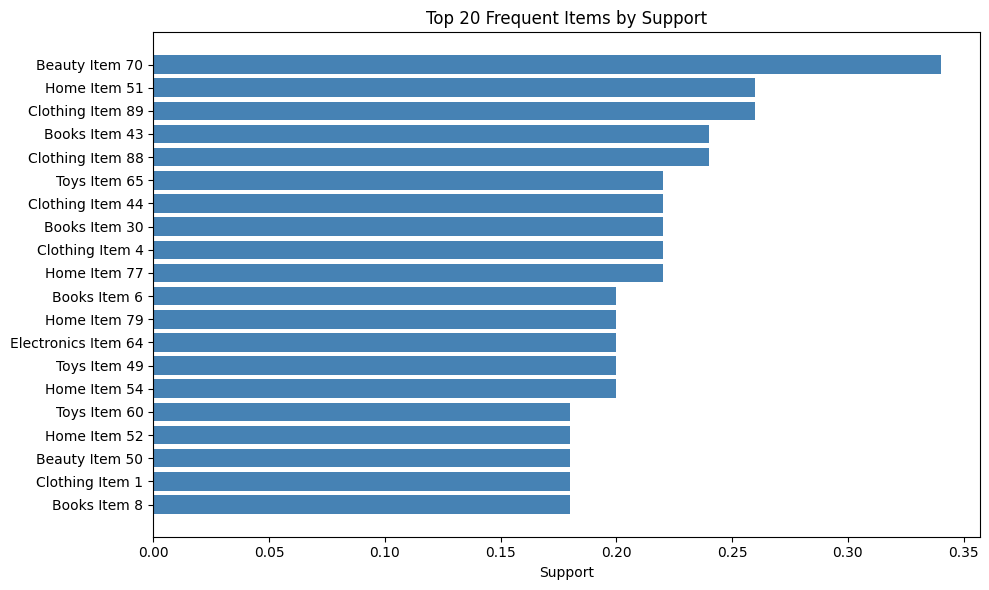

In [65]:
top = frequent_itemsets[frequent_itemsets['length'] == 1].sort_values('support', ascending=False).head(20)
labels = [label_itemset(i) for i in top['itemsets']]

plt.figure(figsize=(10, 6))
plt.barh(labels, top['support'], color='steelblue')
plt.xlabel('Support')
plt.title('Top 20 Frequent Items by Support')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### (3.8) Network Diagram: Association Rules

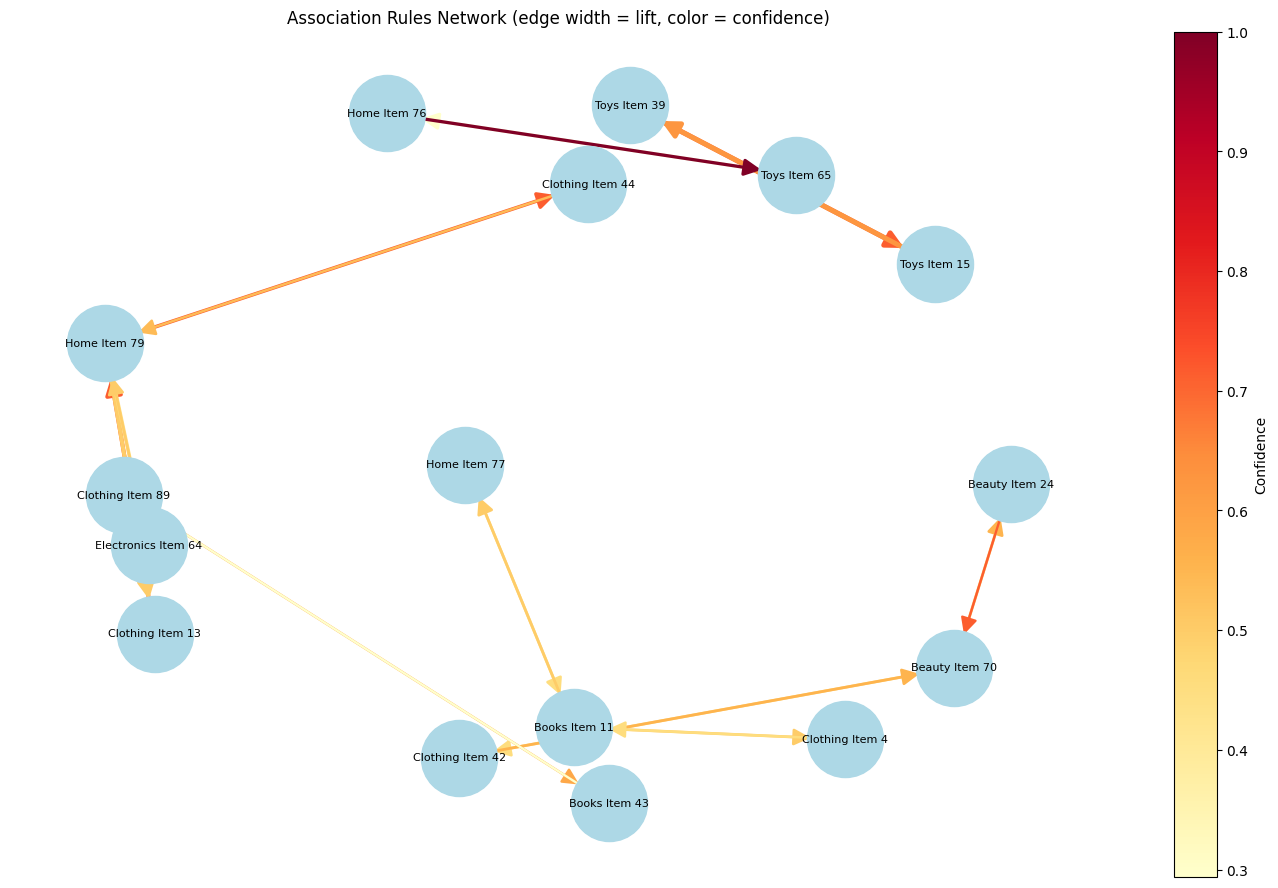

In [57]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import networkx as nx

# Filter to the strongest rules for a cleaner visualization
top_rules = rules.sort_values('lift', ascending=False).head(20)

# Initialize the directed graph
G = nx.DiGraph()
edge_weights = []
edge_colors = []

# Populate the graph with nodes and edges from the rules
for _, row in top_rules.iterrows():
    ant = label_itemset(row['antecedents'])
    con = label_itemset(row['consequents'])
    G.add_edge(ant, con, weight=row['lift'], confidence=row['confidence'])
    edge_weights.append(row['lift'])
    edge_colors.append(row['confidence'])

fig, ax = plt.subplots(figsize=(14, 9))
pos = nx.spring_layout(G, seed=42, k=2)

nx.draw_networkx_nodes(G, pos, node_size=3000, node_color='lightblue', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
nx.draw_networkx_edges(
    G, pos,
    width=[w * 0.8 for w in edge_weights],
    edge_color=edge_colors,
    edge_cmap=plt.cm.YlOrRd,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=25,
    min_source_margin=25,
    min_target_margin=25,
    ax=ax
)

norm = mcolors.Normalize(vmin=min(edge_colors), vmax=max(edge_colors))
sm = cm.ScalarMappable(cmap=plt.cm.YlOrRd, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Confidence')

ax.set_title('Association Rules Network (edge width = lift, color = confidence)')
ax.axis('off')
plt.tight_layout()
plt.show()

## Conclusion

**Overall pattern:** support is low (all 0.1) meaning each rule only appears in 10% of users. The itemsets aren't very frequent, but the relationships between them are meaningful.

### Strongest rules by lift:

**Toys Item 39 <-> Toys Item 15 (lift=4.46)**

Strongest overall association in the data.
71.4% of users who bought Toys Item 39 also bought Toys Item 15.

**Clothing Item 13 <-> Home Item 79 (lift=3.57)**

Strong association with high reliability.
71.4% of users who bought clothing item 13 also bought Home Item 79.

**Clothing Item 4 / Home Item 77 <-> Books Item 11 (lift=2.53)**

55.5% of users who bought Books Item 11 also bought Clothing Item 4 or Home Item 77.

**Clothing Item 3 <-> Beauty Item 70 (lift=1.84)**

Moderate association, 62.5% confidence one way.

# PART 4: ANALYSIS & VISUALIZATION

### 4.1. User Similarity Heatmap

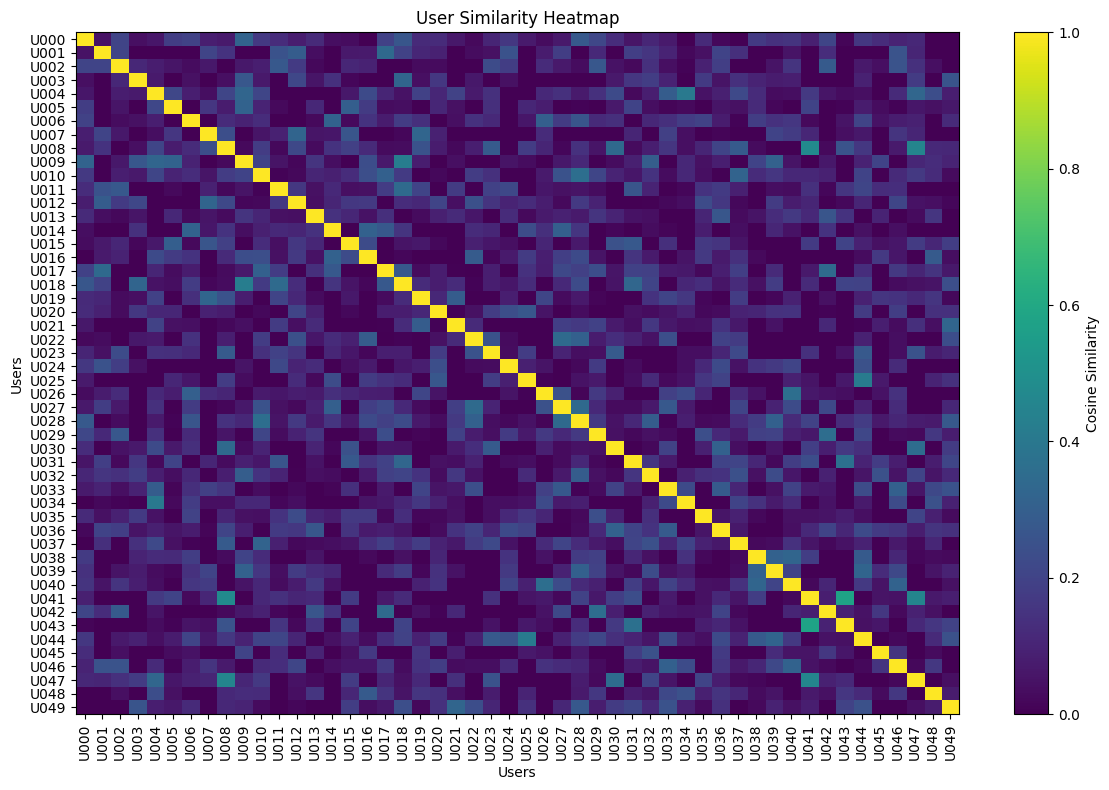

In [58]:
plt.figure(figsize=(12, 8))
plt.imshow(user_similarity_df.values, aspect='auto')

# Add a colorbar to indicate the cosine similarity values
plt.colorbar(label='Cosine Similarity')
plt.xticks(range(len(user_similarity_df.columns)), user_similarity_df.columns, rotation=90)
plt.yticks(range(len(user_similarity_df.index)), user_similarity_df.index)
plt.title("User Similarity Heatmap")
plt.xlabel("Users")
plt.ylabel("Users")
plt.tight_layout()
plt.show()

### 4.2. Top-5 Product Recommendations for Each User


In [59]:
# Build a list of recommendation records for each user
recommendation_rows = []

for user_id in user_item_matrix.index:
    # Get the top N recommended products for this user
    recs = recommend_products(user_id, top_n=5)

    rank = 1
    for product_id, score in recs.items():
        # Lookup the product name and category from the product details table
        product_name = product_details.loc[
            product_details["ProductID"] == product_id, "ProductName"
        ]

        category = product_details.loc[
            product_details["ProductID"] == product_id, "Category"
        ]

        recommendation_rows.append({
            "UserID": user_id,
            "Rank": rank,
            "ProductID": product_id,
            "ProductName": product_name.values[0] if len(product_name) > 0 else product_id,
            "Category": category.values[0] if len(category) > 0 else "Unknown",
            "RecommendationScore": round(score, 4)
        })
        rank += 1

# Convert the accumulated recommendation rows into a DataFrame
recommendations_df = pd.DataFrame(recommendation_rows)

print("Top-5 Recommendations Per User:")
display(recommendations_df.head(20))

Top-5 Recommendations Per User:


,UserID,Rank,ProductID,ProductName,Category,RecommendationScore
0,U000,1,P0040,Electronics Item 40,Home,2.6533
1,U000,2,P0027,Electronics Item 27,Books,2.0188
2,U000,3,P0052,Home Item 52,Books,1.6893
3,U000,4,P0082,Toys Item 82,Books,1.6876
4,U000,5,P0060,Toys Item 60,Home,1.6347
5,U001,1,P0062,Books Item 62,Clothing,2.4019
6,U001,2,P0015,Toys Item 15,Home,2.1316
7,U001,3,P0018,Home Item 18,Electronics,2.0206
8,U001,4,P0064,Electronics Item 64,Electronics,1.9607
9,U001,5,P0008,Books Item 8,Electronics,1.8958


### 4.3. User Groups Based on Favorite Category

In [60]:
# Group the merged data by UserID and Category, count the number of interactions (size), and reset index to create a DataFrame
user_groups = (
    merged_data.groupby(["UserID", "Category"])
    .size()
    .reset_index(name="InteractionCount")
)

# Sort the user_groups DataFrame by UserID (ascending) and InteractionCount (descending), then drop duplicates based on UserID to keep only the category with the highest interactions per user
user_groups = user_groups.sort_values(
    ["UserID", "InteractionCount"], ascending=[True, False]
).drop_duplicates(subset=["UserID"])

# Rename the 'Category' column to 'UserGroup' for clarity
user_groups = user_groups.rename(columns={"Category": "UserGroup"})
print("User Groups Preview:")
display(user_groups.head())

# Merge the recommendations_df with the user_groups DataFrame on UserID to add the UserGroup column to recommendations
recommendations_with_groups = recommendations_df.merge(user_groups[["UserID", "UserGroup"]], on="UserID", how="left")

# Group the recommendations with groups by UserGroup, ProductID, ProductName, and Category, calculate the mean RecommendationScore, and reset index
group_recommendations = (
    recommendations_with_groups.groupby(["UserGroup", "ProductID", "ProductName", "Category"])["RecommendationScore"]
    .mean()
    .reset_index()
)

# Sort the group_recommendations by UserGroup (ascending) and RecommendationScore (descending)
group_recommendations = group_recommendations.sort_values(
    ["UserGroup", "RecommendationScore"], ascending=[True, False]
)

# Select the top 5 recommendations per UserGroup
top5_group_recommendations = group_recommendations.groupby("UserGroup").head(5)

print("Top-5 Recommendations for Each User Group:")
display(top5_group_recommendations)

User Groups Preview:


,UserID,UserGroup,InteractionCount
0,U000,Books,6
6,U001,Books,4
16,U002,Toys,6
17,U003,Beauty,3
23,U004,Books,5


Top-5 Recommendations for Each User Group:


,UserGroup,ProductID,ProductName,Category,RecommendationScore
20,Beauty,P0064,Electronics Item 64,Electronics,3.346100
5,Beauty,P0013,Clothing Item 13,Clothing,3.089500
34,Beauty,P0088,Clothing Item 88,Books,2.953200
24,Beauty,P0069,Beauty Item 69,Toys,2.899500
4,Beauty,P0008,Books Item 8,Electronics,2.846000
93,Books,P0094,Toys Item 94,Electronics,3.634600
79,Books,P0069,Beauty Item 69,Toys,2.680800
41,Books,P0003,Clothing Item 3,Electronics,2.627500
62,Books,P0039,Toys Item 39,Electronics,2.496033
83,Books,P0073,Toys Item 73,Beauty,2.399500


### 4.4 Visualization: Top Recommendations by User Group

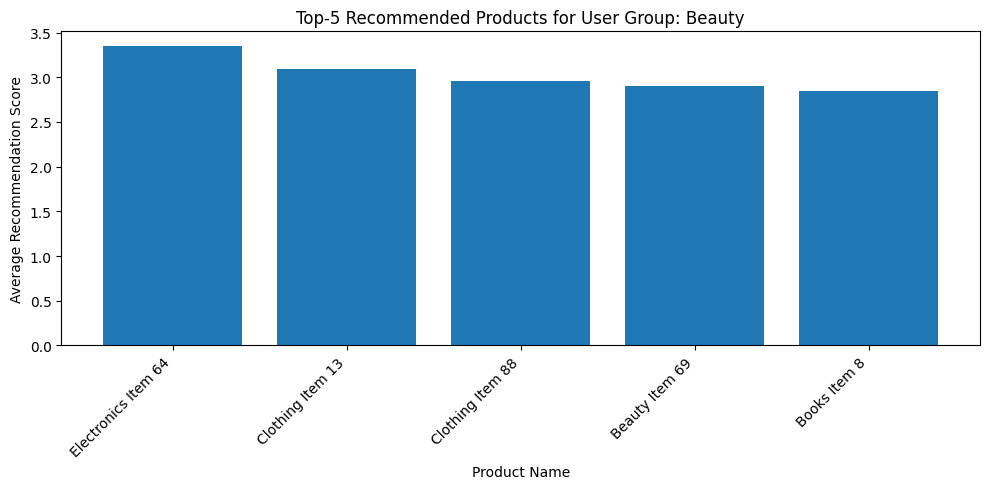

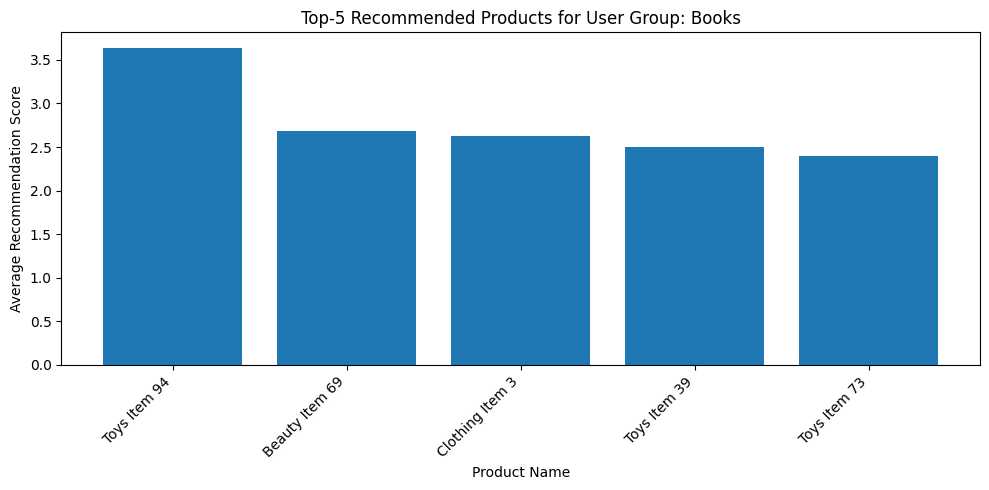

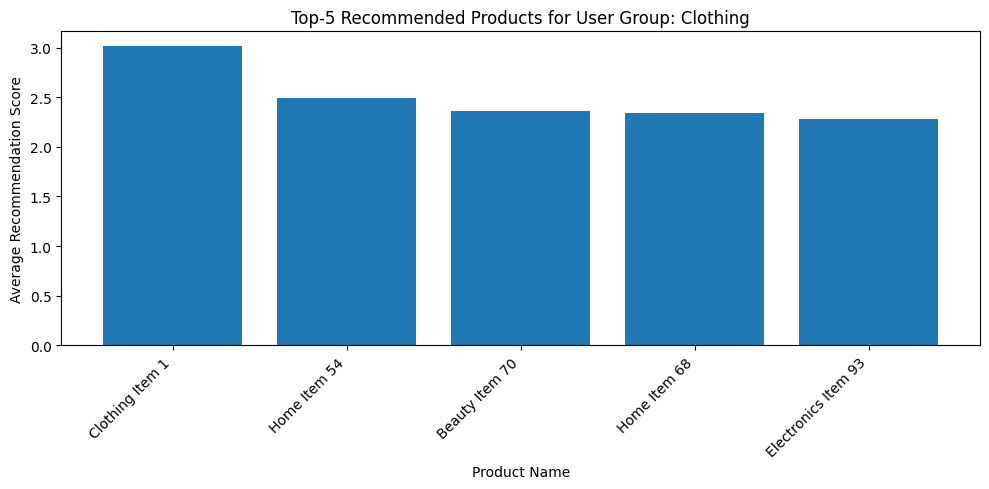

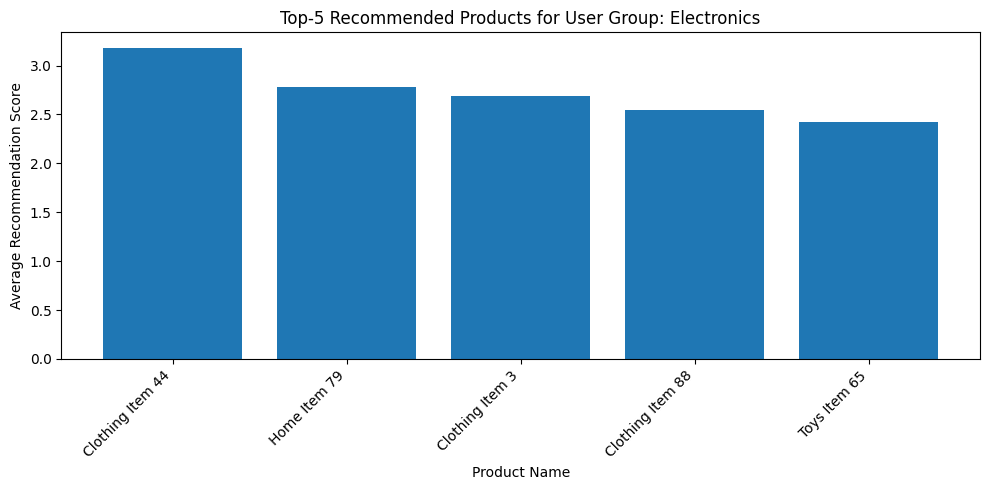

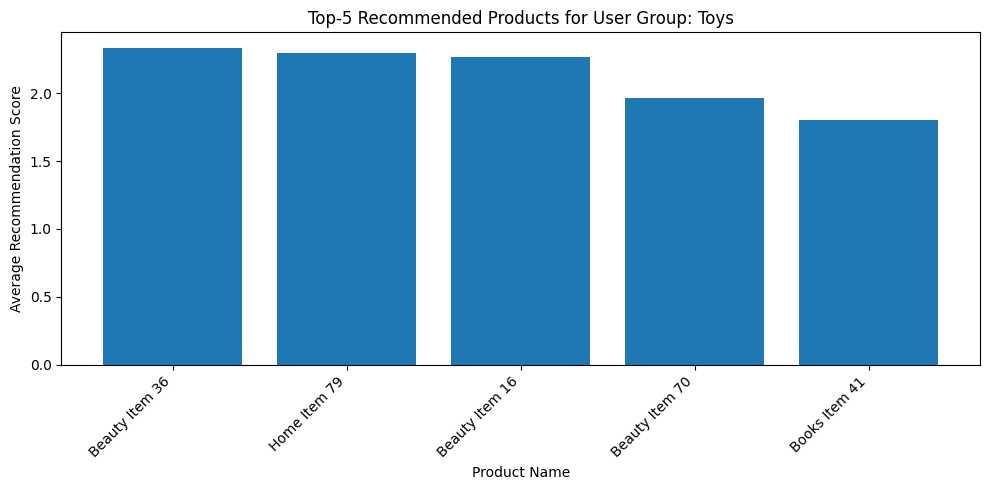

In [62]:
for group in top5_group_recommendations["UserGroup"].unique():
    group_data = top5_group_recommendations[
        top5_group_recommendations["UserGroup"] == group
    ]

    plt.figure(figsize=(10, 5))
    plt.bar(group_data["ProductName"], group_data["RecommendationScore"])
    plt.title(f"Top-5 Recommended Products for User Group: {group}")
    plt.xlabel("Product Name")
    plt.ylabel("Average Recommendation Score")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

### 4.5 Visualization: Number of Users in Each Group

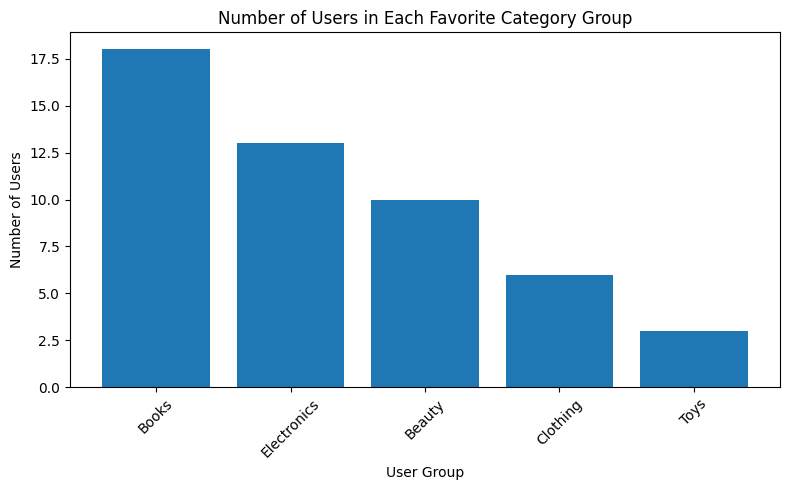

In [61]:
group_counts = user_groups["UserGroup"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(group_counts.index, group_counts.values)
plt.title("Number of Users in Each Favorite Category Group")
plt.xlabel("User Group")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.6. Analysis Summary

- The user similarity heatmap reveals the degree of similarity between users based on their ratings.
- We generate the top 5 recommendations to each user using Collaborative Filtering, based on how other users alike rated the products.
- Users are grouped by the category that they have the most interaction with (i.e., frequent users).
- Group-level recommendations charts tell us which products are of high relevance to the user segment based on the category.
- We provide exported CSV files as outputs for the report or appendix.